<a href="https://colab.research.google.com/github/KETSIAMBATU/TP_SCIENCE_B/blob/main/TP_SCIENCE_B.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

      NUÉES DYNAMIQUES - FROM SCRATCH

Choisir la représentation d'une nuée :
1 - Un point représentatif (K-means)
2 - Plusieurs points représentatifs
3 - Axes factoriels
4 - Distribution
5 - Structure représentative

Votre choix (1-5) : 2

Représentation choisie : points_representatifs

RESULTATS
Nombre de groupes : 3
Nombre d'iterations : 2
Coût : 9.000000000000002

Affectation des observations :
Observation  1 [12. 10.] -> Groupe 2
Observation  2 [13. 11.] -> Groupe 2
Observation  3 [14. 12.] -> Groupe 2
Observation  4 [11.  9.] -> Groupe 2
Observation  5 [5. 6.] -> Groupe 1
Observation  6 [6. 5.] -> Groupe 1
Observation  7 [7. 7.] -> Groupe 1
Observation  8 [5. 5.] -> Groupe 1
Observation  9 [18. 17.] -> Groupe 3
Observation 10 [19. 18.] -> Groupe 3
Observation 11 [17. 16.] -> Groupe 3
Observation 12 [20. 19.] -> Groupe 3

Représentations finales :

Groupe 1 :
Points représentatifs :
[[5. 6.]
 [6. 5.]
 [5. 5.]]

Groupe 2 :
Points représentatifs :
[[12. 10.]
 [13. 11.]
 [14. 12.]]



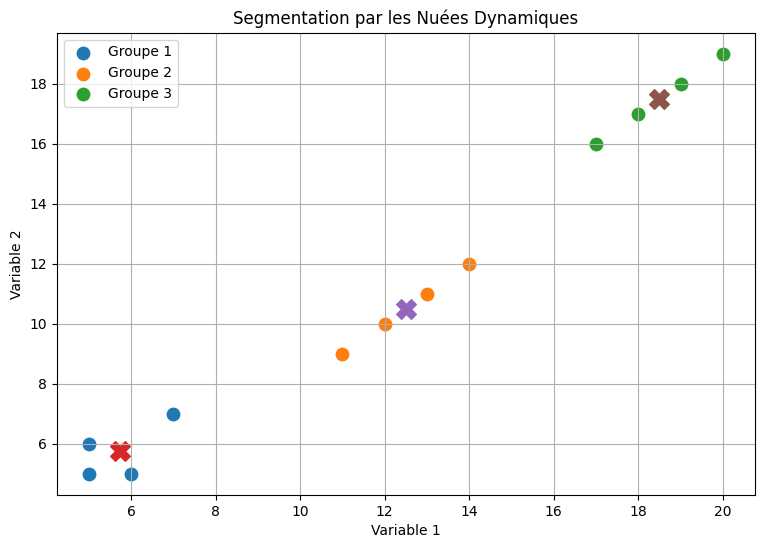

In [9]:

# TP SCIENCE DE DONNÉES
# NUÉES DYNAMIQUES FROM SCRATCH
# ============================================================

import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# 1. JEU DE DONNÉES
# ============================================================

X = np.array([
    [12, 10],
    [13, 11],
    [14, 12],
    [11, 9],
    [5, 6],
    [6, 5],
    [7, 7],
    [5, 5],
    [18, 17],
    [19, 18],
    [17, 16],
    [20, 19]
], dtype=float)


# ============================================================
# 2. DISTANCE EUCLIDIENNE
# ============================================================

def distance_euclidienne(a, b):
    return np.sqrt(np.sum((a - b) ** 2))


# ============================================================
# 3. REPRESENTATION D'UNE NUEE
# ============================================================

def calculer_representation(X_groupe, type_representation):

    if len(X_groupe) == 0:
        return None

    # --------------------------------------------------------
    # POINT REPRESENTATIF = K-MEANS
    # --------------------------------------------------------
    if type_representation == "point":

        centre = np.mean(X_groupe, axis=0)

        return {
            "type": "point",
            "centre": centre
        }

    # --------------------------------------------------------
    # PLUSIEURS POINTS REPRESENTATIFS
    # --------------------------------------------------------
    elif type_representation == "points_representatifs":

        centre = np.mean(X_groupe, axis=0)

        distances = np.array([
            distance_euclidienne(point, centre)
            for point in X_groupe
        ])

        nombre_points = min(3, len(X_groupe))

        indices = np.argsort(distances)[:nombre_points]

        points = X_groupe[indices]

        return {
            "type": "points_representatifs",
            "points": points,
            "centre": centre
        }

    # --------------------------------------------------------
    # AXES FACTORIELS
    # --------------------------------------------------------
    elif type_representation == "axes_factoriels":

        centre = np.mean(X_groupe, axis=0)

        donnees_centrees = X_groupe - centre

        U, S, Vt = np.linalg.svd(
            donnees_centrees,
            full_matrices=False
        )

        return {
            "type": "axes_factoriels",
            "centre": centre,
            "axes": Vt
        }

    # --------------------------------------------------------
    # DISTRIBUTION
    # --------------------------------------------------------
    elif type_representation == "distribution":

        moyenne = np.mean(X_groupe, axis=0)

        if len(X_groupe) > 1:
            covariance = np.cov(X_groupe, rowvar=False)
        else:
            covariance = np.eye(X.shape[1])

        return {
            "type": "distribution",
            "moyenne": moyenne,
            "covariance": covariance
        }

    # --------------------------------------------------------
    # STRUCTURE REPRESENTATIVE
    # --------------------------------------------------------
    elif type_representation == "structure":

        centre = np.mean(X_groupe, axis=0)

        if len(X_groupe) > 1:
            covariance = np.cov(X_groupe, rowvar=False)
        else:
            covariance = np.eye(X.shape[1])

        return {
            "type": "structure",
            "centre": centre,
            "covariance": covariance
        }

    else:
        raise ValueError("Type de représentation inconnu.")


# ============================================================
# 4. DISTANCE ENTRE UNE OBSERVATION ET UNE REPRESENTATION
# ============================================================

def distance_representation(point, representation):

    type_rep = representation["type"]

    # --------------------------------------------------------
    # POINT
    # --------------------------------------------------------
    if type_rep == "point":

        return distance_euclidienne(
            point,
            representation["centre"]
        )

    # --------------------------------------------------------
    # PLUSIEURS POINTS
    # Distance = distance au point représentatif le plus proche
    # --------------------------------------------------------
    elif type_rep == "points_representatifs":

        distances = [
            distance_euclidienne(point, p)
            for p in representation["points"]
        ]

        return min(distances)

    # --------------------------------------------------------
    # AXES FACTORIELS
    # Distance au sous-espace représenté par les axes
    # --------------------------------------------------------
    elif type_rep == "axes_factoriels":

        centre = representation["centre"]
        axes = representation["axes"]

        vecteur = point - centre

        if axes.shape[0] == 0:
            return distance_euclidienne(point, centre)

        axe_principal = axes[0]

        projection = np.dot(vecteur, axe_principal) * axe_principal

        residu = vecteur - projection

        return np.linalg.norm(residu)

    # --------------------------------------------------------
    # DISTRIBUTION
    # Distance de Mahalanobis
    # --------------------------------------------------------
    elif type_rep == "distribution":

        moyenne = representation["moyenne"]
        covariance = representation["covariance"]

        covariance = covariance + np.eye(len(moyenne)) * 1e-6

        vecteur = point - moyenne

        try:
            inverse = np.linalg.inv(covariance)
            distance = np.sqrt(
                np.dot(
                    np.dot(vecteur, inverse),
                    vecteur
                )
            )
            return distance

        except np.linalg.LinAlgError:
            return distance_euclidienne(point, moyenne)

    # --------------------------------------------------------
    # STRUCTURE
    # --------------------------------------------------------
    elif type_rep == "structure":

        centre = representation["centre"]

        distance_centre = distance_euclidienne(
            point,
            centre
        )

        return distance_centre


# ============================================================
# 5. INITIALISATION DES REPRESENTATIONS
# ============================================================

def initialiser_representations(X, K, random_state=42):

    rng = np.random.default_rng(random_state)

    indices = rng.choice(
        len(X),
        size=K,
        replace=False
    )

    representations = []

    for indice in indices:

        representations.append({
            "type": "point",
            "centre": X[indice].copy()
        })

    return representations


# ============================================================
# 6. AFFECTATION DES OBSERVATIONS
# ============================================================

def affecter_groupes(X, representations):

    groupes = []

    for point in X:

        distances = []

        for representation in representations:

            d = distance_representation(
                point,
                representation
            )

            distances.append(d)

        groupe = np.argmin(distances)

        groupes.append(groupe)

    return np.array(groupes)


# ============================================================
# 7. MISE A JOUR DES NUEES
# ============================================================

def mettre_a_jour_representations(
    X,
    groupes,
    K,
    type_representation,
    anciennes_representations
):

    nouvelles_representations = []

    for k in range(K):

        X_groupe = X[groupes == k]

        if len(X_groupe) == 0:

            nouvelles_representations.append(
                anciennes_representations[k]
            )

        else:

            representation = calculer_representation(
                X_groupe,
                type_representation
            )

            nouvelles_representations.append(
                representation
            )

    return nouvelles_representations


# ============================================================
# 8. ALGORITHME DES NUÉES DYNAMIQUES
# ============================================================

def nuees_dynamiques(
    X,
    K,
    type_representation="point",
    max_iterations=100,
    random_state=42
):

    # Initialisation avec des points
    representations = initialiser_representations(
        X,
        K,
        random_state
    )

    for iteration in range(max_iterations):

        # Affectation
        groupes = affecter_groupes(
            X,
            representations
        )

        # Mise à jour
        nouvelles_representations = (
            mettre_a_jour_representations(
                X,
                groupes,
                K,
                type_representation,
                representations
            )
        )

        # Test de stabilisation
        stabilise = True

        for ancienne, nouvelle in zip(
            representations,
            nouvelles_representations
        ):

            if ancienne["type"] != nouvelle["type"]:
                stabilise = False
                break

            if "centre" in ancienne:

                if not np.allclose(
                    ancienne["centre"],
                    nouvelle.get("centre", ancienne["centre"])
                ):
                    stabilise = False
                    break

        representations = nouvelles_representations

        if stabilise:
            break

    return groupes, representations, iteration + 1


# ============================================================
# 9. COUT DE LA SEGMENTATION
# ============================================================

def calculer_cout(
    X,
    groupes,
    representations
):

    cout = 0

    for i, point in enumerate(X):

        representation = representations[groupes[i]]

        d = distance_representation(
            point,
            representation
        )

        cout += d ** 2

    return cout


# ============================================================
# 10. CHOIX DE LA REPRESENTATION
# ============================================================

print("=" * 60)
print("      NUÉES DYNAMIQUES - FROM SCRATCH")
print("=" * 60)

print("\nChoisir la représentation d'une nuée :")
print("1 - Un point représentatif (K-means)")
print("2 - Plusieurs points représentatifs")
print("3 - Axes factoriels")
print("4 - Distribution")
print("5 - Structure représentative")

choix = input("\nVotre choix (1-5) : ")

types = {
    "1": "point",
    "2": "points_representatifs",
    "3": "axes_factoriels",
    "4": "distribution",
    "5": "structure"
}

type_representation = types.get(choix, "point")

print("\nReprésentation choisie :", type_representation)


# ============================================================
# 11. TEST AVEC K = 3
# ============================================================

K = 3

groupes, representations, iterations = nuees_dynamiques(
    X,
    K,
    type_representation=type_representation,
    max_iterations=100,
    random_state=42
)

cout = calculer_cout(
    X,
    groupes,
    representations
)


# ============================================================
# 12. RESULTATS
# ============================================================

print("\n" + "=" * 60)
print("RESULTATS")
print("=" * 60)

print("Nombre de groupes :", K)
print("Nombre d'iterations :", iterations)
print("Coût :", cout)

print("\nAffectation des observations :")

for i, groupe in enumerate(groupes):

    print(
        f"Observation {i+1:2d} "
        f"{X[i]} -> Groupe {groupe + 1}"
    )


# ============================================================
# 13. AFFICHAGE DES REPRESENTATIONS
# ============================================================

print("\nReprésentations finales :")

for k, representation in enumerate(representations):

    print(f"\nGroupe {k+1} :")

    if representation["type"] == "point":

        print(
            "Centre :",
            representation["centre"]
        )

    elif representation["type"] == "points_representatifs":

        print(
            "Points représentatifs :"
        )
        print(
            representation["points"]
        )

    elif representation["type"] == "axes_factoriels":

        print(
            "Centre :",
            representation["centre"]
        )
        print(
            "Axes factoriels :"
        )
        print(
            representation["axes"]
        )

    elif representation["type"] == "distribution":

        print(
            "Moyenne :",
            representation["moyenne"]
        )
        print(
            "Covariance :"
        )
        print(
            representation["covariance"]
        )

    elif representation["type"] == "structure":

        print(
            "Centre :",
            representation["centre"]
        )
        print(
            "Covariance :"
        )
        print(
            representation["covariance"]
        )


# ============================================================
# 14. VISUALISATION
# ============================================================

plt.figure(figsize=(9, 6))

for k in range(K):

    points = X[groupes == k]

    plt.scatter(
        points[:, 0],
        points[:, 1],
        label=f"Groupe {k+1}",
        s=80
    )

# Affichage des centres lorsque disponibles
for representation in representations:

    if "centre" in representation:

        centre = representation["centre"]

        plt.scatter(
            centre[0],
            centre[1],
            marker="X",
            s=200
        )

plt.xlabel("Variable 1")
plt.ylabel("Variable 2")

plt.title(
    "Segmentation par les Nuées Dynamiques"
)

plt.legend()
plt.grid(True)

plt.show()